[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/techaarvam/byom_workshop/blob/main/attention_ann.ipynb)

*Part of the TechAarvam workshop support files — [Build Your Own Model](https://www.techaarvam.com/workshops/build-your-own-model).*

# Attention is simpler than you think
### A hand-crafted superhero transformer

[![Attention is simpler than you think - watch the walkthrough](https://i.ytimg.com/vi/a_5qWhiyEOw/maxresdefault.jpg)](https://youtu.be/a_5qWhiyEOw)

▶ **[Watch the 2-minute walkthrough](https://youtu.be/a_5qWhiyEOw)** — the same example, drawn by hand.

This notebook presents a hand-crafted example. The goal is to understand the intuition behind the attention block in the transformer architecture.

Attention and FFN are the two main components. FFN is an Artificial neural network (ANN) with 1 input, 1 hidden, and 1 output layer.

So we start constructing the FFN's job by hand. Then we show how Attention extracts what the FFN can use from a sentence. The sentences used and the vocabulary are intentionally hand-designed to be simple. The attention block weights are hand-coded, instead of trained. The ANN(FFN) is trained.

<img src="https://raw.githubusercontent.com/techaarvam/byom_workshop/main/assets/transformer_map_08.svg" alt="Where notebook 08 fits in the transformer" width="560">

```mermaid
flowchart LR
    T(["input tokens"]) --> A["Attention"] --> N["ANN"] --> S(["scores"])

    classDef io fill:#F1F1F1,stroke:#9E9E9E,color:#222
    classDef attn fill:#DCEBFA,stroke:#93B4D6,color:#222
    classDef ann fill:#D8F3DC,stroke:#8FC39A,color:#222
    class T,S io
    class A attn
    class N ann
```

In [1]:
import numpy as np

np.set_printoptions(precision=2, suppress=True)

<img src="https://raw.githubusercontent.com/techaarvam/byom_workshop/main/assets/cues/08_01.svg" alt="Part 1: ANN vocabulary" height="48">

---
## 1. Artificial Neural Network

### 1.1 Vocabulary for the ANN

| Word | can fly? | has wheels? | can speak? |
| :--- | :---: | :---: | :---: |
| Rock | 0 | 0 | 0 |
| Human | 0 | 0 | 1 |
| Car | 0 | 1 | 0 |
| Talking Tow Truck | 0 | 1 | 1 |
| Crow | 1 | 0 | 0 |
| Flying Superhero | 1 | 0 | 1 |
| Plane | 1 | 1 | 0 |
| Talking Planes | 1 | 1 | 1 |

In [2]:
word_to_attributes = {
    "Rock":              (0, 0, 0),
    "Human":             (0, 0, 1),
    "Car":               (0, 1, 0),
    "Talking Tow Truck": (0, 1, 1),
    "Crow":              (1, 0, 0),
    "Flying Superhero":  (1, 0, 1),
    "Plane":             (1, 1, 0),
    "Talking Planes":    (1, 1, 1),
}

for word, bits in word_to_attributes.items():
    print(f"{word:20} {bits}")

Rock                 (0, 0, 0)
Human                (0, 0, 1)
Car                  (0, 1, 0)
Talking Tow Truck    (0, 1, 1)
Crow                 (1, 0, 0)
Flying Superhero     (1, 0, 1)
Plane                (1, 1, 0)
Talking Planes       (1, 1, 1)


<img src="https://raw.githubusercontent.com/techaarvam/byom_workshop/main/assets/cues/08_02.svg" alt="ANN&#x27;s learning goal" height="48">

### 1.2 ANN's learning goal

The ANN takes as input the objects attributes - 3 bits. And also takes as input 3-bits of correction.

The ANN outputs scores for each token ( we have 8 possible next word tokens ) - ANN's learning goal is to give 8 scores.
Such scores are called logits. 

Softmax is a math function that can take scores and convert them into probabilities (i.e each item is 0 to 1; total = 1)



The input is fixed bit-encoding of 6 bits.

    Input word  - 3 bits
    Correction  - 3 bits
    Output word - attributes after the correction

Lets say rock: (attributes: speak:0, fly:0, wheels:0)
Correction ( attributes: speak:1, fly:0, wheels: 0) . 
   For the above example: "Human" must have the largest score. 


### 1.3 Example

1. Rock + add flight -> Plane
2. Human + add flight -> Flying Superhero

In [3]:
attributes_to_word = {bits: word for word, bits in word_to_attributes.items()}


def apply_correction(word, correction):
    """Correction is 3 bits: 1 means flip that attribute."""
    bits = word_to_attributes[word]
    out = tuple(b ^ c for b, c in zip(bits, correction))
    return attributes_to_word[out]


print(apply_correction("Rock", (1, 0, 0)))   # add flight
print(apply_correction("Human", (1, 0, 0)))  # add flight

Crow
Flying Superhero


### 1.4 Training the ANN: Pseudocode

In [4]:
# Pseudocode - not run here.
#
# for loop in range (num_epochs):
#     for batch_inputs, batch_targets in loader:
#         prediction = model.forward(batch_inputs)          # predict
#         loss = CrossEntropyLoss(prediction, target)       # how far off?
#         loss.backward()                                   # gradient descent

In the full workshop, the notebook with the full ANN implementation is available. Visit the relevant TechAarvam pages to locate them.

<img src="https://raw.githubusercontent.com/techaarvam/byom_workshop/main/assets/cues/08_03.svg" alt="Part 2: Attention block" height="48">

---
## 2. Attention Block

Input is now a sentence:

> **Crow keep-flight swap-speech he-is?**

Sentences have complex structure. Word order varies.
So: fixed sentence structure, small defined vocabulary.

    Objects:       Rock, Human, Crow, Flying superhero
    Actions:       swap-flight, swap-speech, keep-flight, keep-speech
    Interrogative: he-is?

<img src="https://raw.githubusercontent.com/techaarvam/byom_workshop/main/assets/cues/08_04.svg" alt="Tokens to vectors" height="48">

### 2.1 Tokens to vectors

8-bit vectors, shown as 4 + 4.

**Bits 1-4 - attributes and correction:**

| Token | can fly | can speak | swap flight | swap speech |
| :--- | :---: | :---: | :---: | :---: |
| Rock | 0 | 0 | 0 | 0 |
| Human | 0 | 1 | 0 | 0 |
| Crow | 1 | 0 | 0 | 0 |
| Flying superhero | 1 | 1 | 0 | 0 |
| swap-flight | 0 | 0 | 1 | 0 |
| swap-speech | 0 | 0 | 0 | 1 |
| keep-flight | 0 | 0 | 0 | 0 |
| keep-speech | 0 | 0 | 0 | 0 |
| he-is? | 0 | 0 | 0 | 0 |

**Bits 5-8 - token type:**

| Token | object? | flight act? | speech act? | question? |
| :--- | :---: | :---: | :---: | :---: |
| Rock | 1 | 0 | 0 | 0 |
| Human | 1 | 0 | 0 | 0 |
| Crow | 1 | 0 | 0 | 0 |
| Flying superhero | 1 | 0 | 0 | 0 |
| swap-flight | 0 | 1 | 0 | 0 |
| swap-speech | 0 | 0 | 1 | 0 |
| keep-flight | 0 | 1 | 0 | 0 |
| keep-speech | 0 | 0 | 1 | 0 |
| he-is? | 0 | 0 | 0 | 1 |

In [5]:
bit_labels = ["can fly", "can speak", "swap flight", "swap speech",
        "object?", "flight act?", "speech act?", "question?"]

token_to_bitvec = {
    #                    fly spk swF swS  obj flA spA  q
    "Rock":             [0,  0,  0,  0,   1,  0,  0,  0],
    "Human":            [0,  1,  0,  0,   1,  0,  0,  0],
    "Crow":             [1,  0,  0,  0,   1,  0,  0,  0],
    "Flying superhero": [1,  1,  0,  0,   1,  0,  0,  0],
    "swap-flight":      [0,  0,  1,  0,   0,  1,  0,  0],
    "swap-speech":      [0,  0,  0,  1,   0,  0,  1,  0],
    "keep-flight":      [0,  0,  0,  0,   0,  1,  0,  0],
    "keep-speech":      [0,  0,  0,  0,   0,  0,  1,  0],
    "he-is?":           [0,  0,  0,  0,   0,  0,  0,  1],
}

token_to_bitvec = {k: np.array(v) for k, v in token_to_bitvec.items()}

for tok, v in token_to_bitvec.items():
    print(f"{tok:18} {v[:4]}  {v[4:]}")

Rock               [0 0 0 0]  [1 0 0 0]
Human              [0 1 0 0]  [1 0 0 0]
Crow               [1 0 0 0]  [1 0 0 0]
Flying superhero   [1 1 0 0]  [1 0 0 0]
swap-flight        [0 0 1 0]  [0 1 0 0]
swap-speech        [0 0 0 1]  [0 0 1 0]
keep-flight        [0 0 0 0]  [0 1 0 0]
keep-speech        [0 0 0 0]  [0 0 1 0]
he-is?             [0 0 0 0]  [0 0 0 1]


### 2.2 The sentence

In [6]:
sentence = ["Crow", "keep-flight", "swap-speech", "he-is?"]

X = np.stack([token_to_bitvec[t] for t in sentence])
print(X.shape)
X

(4, 8)


array([[1, 0, 0, 0, 1, 0, 0, 0],
       [0, 0, 0, 0, 0, 1, 0, 0],
       [0, 0, 0, 1, 0, 0, 1, 0],
       [0, 0, 0, 0, 0, 0, 0, 1]])

<img src="https://raw.githubusercontent.com/techaarvam/byom_workshop/main/assets/cues/08_05.svg" alt="Attention math" height="48">

### 2.3 Attention Math

Skip the equations and go to the hand-written Q, K, V weights to get the idea behind these equations first. 

N heads. Each head does:

$$\operatorname{Attention}(Q,K,V)=\operatorname{softmax}\!\left(\frac{QK^{T}}{\sqrt{d_h}}+M\right)V$$

- $QK^T$ - pairwise scores
- softmax - normalize
- $V$ - send the payload

In [7]:
def softmax(z, axis=-1):
    z = z - z.max(axis=axis, keepdims=True)
    e = np.exp(z)
    return e / e.sum(axis=axis, keepdims=True)


def head(X, Wq, Wk, Wv):
    Q, K, V = X @ Wq, X @ Wk, X @ Wv
    d_h = Wq.shape[1]
    scores = Q @ K.T / np.sqrt(d_h)
    A = softmax(scores)
    return A @ V, A, Q, K, V

<img src="https://raw.githubusercontent.com/techaarvam/byom_workshop/main/assets/cues/08_11.svg" alt="Two heads at a glance" height="48">

### 2.4 Two heads at a glance

Each head scores every pair of words: rows ask (queries), columns answer (keys). In both heads only the `he-is?` row asks a question. The bright cells decide which words send their payload bits.

<img src="https://raw.githubusercontent.com/techaarvam/byom_workshop/main/assets/attention_two_heads.svg" alt="For Crow keep-flight swap-speech he-is? and Flying superhero swap-flight keep-speech he-is?, the object head's QK-transpose grid is bright only at he-is? by the object word, and the action head's grid is bright at he-is? by the two action words. The bright cells send the object attributes and the correction: 1 0 0 1 gives Flying superhero, and 1 1 1 0 gives Human." width="900">

<img src="https://raw.githubusercontent.com/techaarvam/byom_workshop/main/assets/cues/08_06.svg" alt="Hand-written heads" height="48">

### 2.5 Hand-written heads

Q - Query. K - Key. V - Value (payload).

The Q, K, V are intermediate tensors, what the model has are the corresponding weights. 
The weight matrices transform the input in three ways to get the (Q, K, V).

$$Q = X\,W_Q \qquad K = X\,W_K \qquad V = X\,W_V$$

X is the input. Its the full sentence in our example. A context length full of tokens as input. 
The three weight matrices transform the input. The three matrices perform - three tasks. 
The weight matrices are per-head. i.e each head can extract out different information from the tokens. 

$W_Q$ is weights for getting the queries for this head.
$W_K$ are the weights that transform the input tokens to keys. (keys are like answers to the queries)
$W_V$ is the payload, if the question and the answer for a pair of tokens get a high score, the W_V helps extract the payload or values from the tokens to pass along towards the FFN (toward the concatenation operation, then the FFN).


Every word asks a question; And also the question is not the same across heads. Each word in Each head can ask a different question; We have two heads in this hand-constructed example (Object Head, Action Verb-Object head)
Object head - `he-is?` asks: are you an Object?

Keys answer. Every token answers.
Object head - "Crow" replies: I am an Object.

<img src="https://raw.githubusercontent.com/techaarvam/byom_workshop/main/assets/cues/08_07.svg" alt="Object head weights" height="48">

### 2.6 Object Head - weights

- Row 8 -> query `he-is?` in the object head asks - are you an object?
- Row 5 -> key replies to this question. (i.e every token replies)
- Rows 1-2 -> payload is can fly, can speak. (Every token can have a payload, and tokens with high-scores get to send their payload)

In [8]:
Wq1 = np.zeros((8, 2)); Wq1[7] = [50, 0]
Wk1 = np.zeros((8, 2)); Wk1[4] = [1, 0]
Wv1 = np.zeros((8, 2)); Wv1[0] = [1, 0]; Wv1[1] = [0, 1]

print("Wq1\n", Wq1, "\n\nWk1\n", Wk1, "\n\nWv1\n", Wv1)

Wq1
 [[ 0.  0.]
 [ 0.  0.]
 [ 0.  0.]
 [ 0.  0.]
 [ 0.  0.]
 [ 0.  0.]
 [ 0.  0.]
 [50.  0.]] 

Wk1
 [[0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [1. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]] 

Wv1
 [[1. 0.]
 [0. 1.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]]


<img src="https://raw.githubusercontent.com/techaarvam/byom_workshop/main/assets/cues/08_08.svg" alt="Action head weights" height="48">

### 2.7 Action (Verb-Object) Head - weights

- Row 8 -> `he-is?` queries both slots
- Rows 6-7 -> keys are the two action types
- Rows 3-4 -> payload is swap flight, swap speech

In [9]:
Wq2 = np.zeros((8, 2)); Wq2[7] = [50, 50]
Wk2 = np.zeros((8, 2)); Wk2[5] = [1, 0]; Wk2[6] = [0, 1]
Wv2 = np.zeros((8, 2)); Wv2[2] = [1, 0]; Wv2[3] = [0, 1]

print("Wq2\n", Wq2, "\n\nWk2\n", Wk2, "\n\nWv2\n", Wv2)

Wq2
 [[ 0.  0.]
 [ 0.  0.]
 [ 0.  0.]
 [ 0.  0.]
 [ 0.  0.]
 [ 0.  0.]
 [ 0.  0.]
 [50. 50.]] 

Wk2
 [[0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [1. 0.]
 [0. 1.]
 [0. 0.]] 

Wv2
 [[0. 0.]
 [0. 0.]
 [1. 0.]
 [0. 1.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]]


### 2.8 Object head: Derive K, V from the weights: Focus on the Crow

Crow, bits 1-8: `1 0 0 0 1 0 0 0`

The payload is Crow's object attributes.

In [10]:
crow = token_to_bitvec["Crow"]
heis = token_to_bitvec["he-is?"]

print("x_Crow           ", crow)
print("x_Crow @ Wk1     ", crow @ Wk1, "  <- key: I am an object")
print("x_Crow @ Wv1     ", crow @ Wv1, "  <- value: [can fly, can speak]")

print("x_he_is @ Wq1     ", heis @ Wq1, "  <- Are you an object?")



x_Crow            [1 0 0 0 1 0 0 0]
x_Crow @ Wk1      [1. 0.]   <- key: I am an object
x_Crow @ Wv1      [1. 0.]   <- value: [can fly, can speak]
x_he_is @ Wq1      [50.  0.]   <- Are you an object?


### 2.9 Action head: Derive K, V from the weights: Focus on the swap-flight

swap-flight, bits 1-8: `0 0 1 0 0 1 0 0`

The payload is the correction.

In [11]:
sf = token_to_bitvec["swap-flight"]

print("x_swap-flight        ", sf)
print("x_swap-flight @ Wk2  ", sf @ Wk2, "  <- key: I am a flight action")
print("x_swap-flight @ Wv2  ", sf @ Wv2, "  <- value: [swap flight, swap speech]")

x_swap-flight         [0 0 1 0 0 1 0 0]
x_swap-flight @ Wk2   [1. 0.]   <- key: I am a flight action
x_swap-flight @ Wv2   [1. 0.]   <- value: [swap flight, swap speech]


### 2.10 Both heads: Derive Q from the weights: Focus on he-is?

`he-is?` is the last token, so we read row 3 of the attention matrix.

In [12]:
out1, A1, Q1, K1, V1 = head(X, Wq1, Wk1, Wv1)
out2, A2, Q2, K2, V2 = head(X, Wq2, Wk2, Wv2)

q = sentence.index("he-is?")

print("Object head - attention from he-is?")
for tok, k, a in zip(sentence, K1, A1[q]):
    print(f"  {tok:14} key={k}  softmax={a:.2f}")
print("  head 1 output:", out1[q])

print("\nAction head - attention from he-is?")
for tok, k, a in zip(sentence, K2, A2[q]):
    print(f"  {tok:14} key={k}  softmax={a:.2f}")
print("  head 2 output:", out2[q])

Object head - attention from he-is?
  Crow           key=[1. 0.]  softmax=1.00
  keep-flight    key=[0. 0.]  softmax=0.00
  swap-speech    key=[0. 0.]  softmax=0.00
  he-is?         key=[0. 0.]  softmax=0.00
  head 1 output: [1. 0.]

Action head - attention from he-is?
  Crow           key=[0. 0.]  softmax=0.00
  keep-flight    key=[1. 0.]  softmax=0.50
  swap-speech    key=[0. 1.]  softmax=0.50
  he-is?         key=[0. 0.]  softmax=0.00
  head 2 output: [0.  0.5]


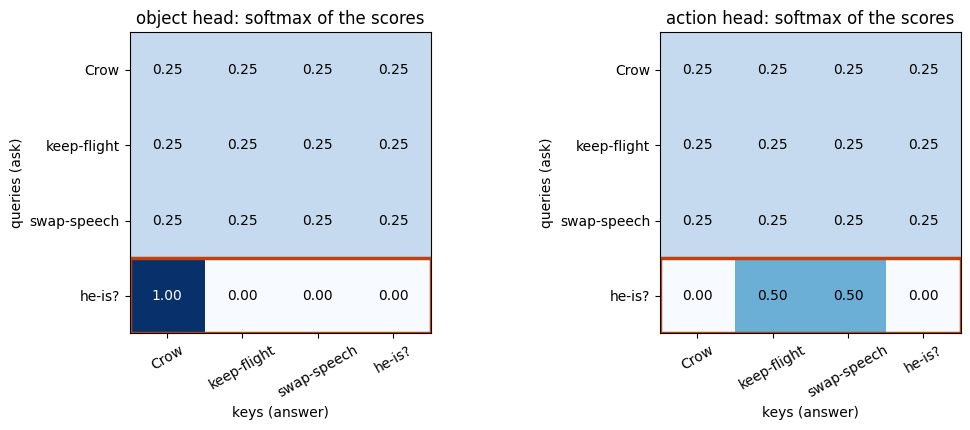

In [13]:
import matplotlib.pyplot as plt  # Draws the full attention matrices.

# The full pairwise matrix: every query row against every key column.
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
for ax, A, title in [(axes[0], A1, "object head"), (axes[1], A2, "action head")]:
    ax.imshow(A, cmap="Blues", vmin=0, vmax=1)
    for r in range(len(sentence)):
        for c in range(len(sentence)):
            ax.text(c, r, f"{A[r, c]:.2f}", ha="center", va="center",
                    color="white" if A[r, c] > 0.6 else "black")
    ax.set_xticks(range(len(sentence)), sentence, rotation=30)
    ax.set_yticks(range(len(sentence)), sentence)
    ax.set(title=f"{title}: softmax of the scores", xlabel="keys (answer)", ylabel="queries (ask)")
    ax.add_patch(plt.Rectangle((-0.5, q - 0.5), len(sentence), 1,
                               fill=False, edgecolor="#c2410c", linewidth=2.5))
plt.tight_layout()
plt.show()

Every cell is a pair score, not one score per word. Only the `he-is?` row asks a question, so only that row focuses. The other rows have all-zero queries, so softmax spreads them evenly (0.25 each); their outputs are not used here.

Two action words split the mass, so head 2 gives `[0, 0.5]`.
$W_O$ scales by 2 -> `[0, 1]`.

<img src="https://raw.githubusercontent.com/techaarvam/byom_workshop/main/assets/cues/08_09.svg" alt="Concatenate the heads" height="48">

### 2.11 Concat: 4 bits out

$$\underbrace{[\,1,\ 0\,]}_{\text{head 1}}\ \Vert\ \underbrace{[\,0,\ 1\,]}_{\text{head 2}}=[\,1,\ 0,\ 0,\ 1\,]$$

In [14]:
Wo = np.diag([1.0, 1.0, 2.0, 2.0])   # head 2 mass was split across 2 words

concat = np.concatenate([out1[q], out2[q]])
final = concat @ Wo

print("concat        ", concat)
print("after W_O     ", final)
print()
for name, val in zip(bit_labels[:4], final):
    print(f"  {name:12} {val:.0f}")

concat         [1.  0.  0.  0.5]
after W_O      [1. 0. 0. 1.]

  can fly      1
  can speak    0
  swap flight  0
  swap speech  1


<img src="https://raw.githubusercontent.com/techaarvam/byom_workshop/main/assets/cues/08_10.svg" alt="Attention output into the ANN" height="48">

Hand-built weights pulled the object attributes and the
correction attributes into 4 bits.

Crow: flies, no speech. Correction: swap speech.
-> Flying superhero. Same 4 bits the ANN wanted.

In [15]:
fly, speak, swap_fly, swap_speak = (int(v) for v in final.round())

obj_in = (fly, 0, speak)                       # ANN bits: fly, wheels, speak
correction = (swap_fly, 0, swap_speak)

print("object in :", attributes_to_word[obj_in])
print("correction:", correction)
print("object out:", apply_correction(attributes_to_word[obj_in], correction))

object in : Crow
correction: (0, 0, 1)
object out: Flying Superhero


**Continue to Part 2:** [Introduce position embedding, residuals and layers](https://colab.research.google.com/github/techaarvam/byom_workshop/blob/main/attention_ann_part2_puzzle_solution.ipynb)

---

<img src="https://raw.githubusercontent.com/techaarvam/byom_workshop/main/assets/techaarvam_logo.png" alt="Tech Aarvam - Dream Build Inspire" width="140">

### About this file

This notebook is part of the support files for the TechAarvam workshop
**[Build Your Own Model](https://www.techaarvam.com/workshops/build-your-own-model)**.

- Website: <https://www.techaarvam.com>
- Workshop files repository: <https://github.com/techaarvam/byom_workshop>
- YouTube: <https://www.youtube.com/@TechAarvam>

© TechAarvam. You are free to use, copy, modify, share and build on this
material, including for commercial purposes, **provided you credit
TechAarvam** and link back to <https://www.techaarvam.com>. Please keep
this notice with any copy or derivative. Provided as-is, without warranty.